## **Understand data structure for SMS datasets, at the same time need to clean the dataset**

##**1.0 Upload SMS Dataset**

In [1]:
#Import Library
import pandas as pd
import numpy as np
import re

##2.0 Upload files

In [4]:
#Upload files
import pandas as pd
df = pd.read_csv(r"C:\Users\Hasya-ZanrooMY\Desktop\Nexpert_Hackathon\Datasets\spam.csv", encoding="latin-1")

In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


##3.0 check Data Structure

In [6]:
df.info()
df.head()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

Columns:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

| Column     | Meaning              |
| ---------- | -------------------- |
| v1         | label (spam / ham) ✅ |
| v2         | SMS text ✅           |
| Unnamed: 2 | mostly empty ❌       |
| Unnamed: 3 | mostly empty ❌       |
| Unnamed: 4 | mostly empty ❌       |

-> have 5 columns, but only 2 are useful (ONLY v1 and v2 USEFUL)



The dataset initially contained extra columns (e.g., "Unnamed: 2, 3, 4") with mostly missing values. These columns were removed as they do not contribute to the analysis.

The dataset consists of two main columns:

v1, which represents the class label (spam or non-spam), and

v2, which contains the raw SMS message text used for classification.

So, these column need to be renamed into label, and text

In [7]:
df = df[['v1', 'v2']]
df = df.rename(columns={
    'v1': 'label',
    'v2': 'text'
})

**Check Data Betul ke tak**

In [8]:
df.head()
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

**5.0 Check Missing Values And Duplicates**

In [9]:
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

label    0
text     0
dtype: int64
Duplicate rows: 403


In [10]:
#remove all the duplicates value
df = df.dropna()
df = df.drop_duplicates()

**6.0 Clean text**

for spam/scam detection, we cannot over clean the data since !, @, #, can be helpful for the ml to understand it is scam/fraud/spam

In [11]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['text'] = df['text'].apply(clean_text)

**7.0 Checking the label is it text or number**

In [12]:
df['label'].unique()

array(['ham', 'spam'], dtype=object)

`array(['ham', 'spam'], dtype=object)` -> if the output is this, it means the label still text and its normal

**8.0 Change Label Text to Number**

In [13]:
df['label'] = df['label'].map({
    'ham': 0, #NOT SPAM
    'spam': 1 #SPAM
})

**9.0 Check mapping berjaya atau tak**

In [14]:
df['label'].value_counts()
df.head(20)

,label,text
0,0,"go until jurong point, crazy.. available only ..."
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,"nah i don't think he goes to usf, he lives aro..."
5,1,freemsg hey there darling it's been 3 week's n...
6,0,even my brother is not like to speak with me. ...
7,0,as per your request 'melle melle (oru minnamin...
8,1,winner!! as a valued network customer you have...
9,1,had your mobile 11 months or more? u r entitle...


**11.0 save and lean dataset**

In [15]:
df.to_csv("clean_sms.csv", index=False)

# **EDA After data clean**

In [16]:
#Basic Dataset Overview

print("Dataset Shape:", df.shape)
print("\nLabel Distribution:")
print(df['label'].value_counts())

Dataset Shape: (5169, 2)

Label Distribution:
label
0    4516
1     653
Name: count, dtype: int64


5169 rows → total SMS messages
2 columns → label and text

The dataset contains 5,169 cleaned and unique SMS messages with two main features label and text

0 → 4516  (not spam)

1 → 653 (spam)

>>Most messages are non-spam, while spam messages form a smaller portion of the datasets.

>>The ML Model might bias toward predicting "ham", accuracy alone can be misleading



> The dataset contains 5,169 SMS messages, where 4,516 are labeled as ham and 653 as spam. This indicates a class imbalance, which may affect model performance. Therefore, evaluation metrics such as precision, recall, and F1-score will be considered instead of relying solely on accuracy.



Total rows after cleaning
Spam vs ham balance


Message Length Stats:
        count        mean        std   min    25%    50%    75%    max
label                                                                 
0      4516.0   70.333702  56.232798   2.0   34.0   52.0   90.0  910.0
1       653.0  137.843798  30.116952  13.0  132.0  149.0  157.0  224.0


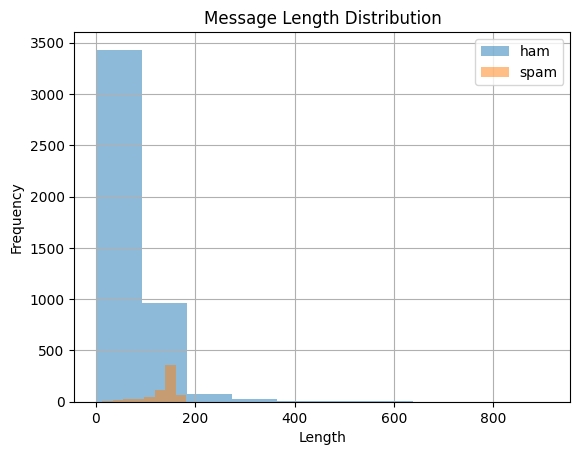

In [17]:
#2. Message Length Analysis
df['length'] = df['text'].apply(len) #convert each message into numeric feature (length)

print("\nMessage Length Stats:")
print(df.groupby('label')['length'].describe()) #statistical summary


import matplotlib.pyplot as plt
#visualization (histogram)
df[df['label']==0]['length'].hist(alpha=0.5, label='ham') #blue = ham
df[df['label']==1]['length'].hist(alpha=0.5, label='spam') #orange = spam

plt.legend()
plt.title("Message Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()


> The distribution shows a clear difference between spam and ham messages. Spam messages are generally longer and fall within a consistent range, while ham messages are shorter and more varied. This indicates that message length is a useful feature for distinguishing between the two classes.


In [18]:
#Most Common Words
from collections import Counter

all_words = ' '.join(df['text']) #combine all SMS into 1 long text
words = re.findall(r'\w+', all_words) #extract all words

common_words = Counter(words).most_common(20)

print("\nTop 20 Common Words:")
for word, count in common_words:
    print(word, count)


Top 20 Common Words:
i 2832
you 2143
to 2070
a 1293
the 1234
u 1062
and 929
in 826
is 793
me 753
my 687
it 686
for 660
your 623
that 560
of 559
s 542
have 538
call 499
on 493


feature exractio (remove stopwords) it will be helpful in tf-idf later



> Stopwords are not removed during preprocessing to preserve important contextual information. Instead, stopword filtering is applied during the TF-IDF feature extraction stage.

> TF-IDF = Term Frequency - Inverse Document Frequency (It’s a method to convert text → numbers so machine learning models can understand it.)


In [19]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

filtered_words = [
    word for word in words if word not in ENGLISH_STOP_WORDS
]

common_words = Counter(filtered_words).most_common(20)

print("\nTop 20 Meaningful Words:")
for word, count in common_words:
    print(word, count)


Top 20 Meaningful Words:
u 1062
s 542
2 486
t 441
m 413
just 345
ur 317
gt 288
lt 287
4 285
ok 260
free 251
å 251
know 243
ll 236
like 234
got 232
good 227
come 213
time 210


> Initial word frequency analysis was dominated by common stopwords (e.g., “the”, “is”, “you”). After removing these, more meaningful terms such as “free”, “call”, and “claim” emerged, which are strong indicators of spam messages.

> Removing stopwords improves feature quality by focusing on informative words, which enhances model performance in text classification tasks.

In [20]:
spam_words = ' '.join(df[df['label']==1]['text']) #only take soam only
words = re.findall(r'\w+', spam_words) #pecahkan jadi list of words

filtered_words = [
    word for word in words if word not in ENGLISH_STOP_WORDS #buang stopwords (the, is, you)
]

Counter(filtered_words).most_common(20) #find 20 words that always show in the spam

[('å', 247),
 ('free', 195),
 ('2', 184),
 ('u', 147),
 ('txt', 134),
 ('ur', 119),
 ('4', 114),
 ('mobile', 109),
 ('stop', 109),
 ('text', 108),
 ('claim', 96),
 ('reply', 96),
 ('1', 93),
 ('www', 83),
 ('prize', 82),
 ('t', 76),
 ('s', 75),
 ('just', 67),
 ('cash', 65),
 ('150p', 64)]

> Analysis of spam messages reveals the frequent use of promotional and action-oriented keywords such as “free”, “claim”, “prize”, and “reply”. These words indicate common scam patterns where users are encouraged to take immediate action or respond to offers, making them strong indicators for classification.

In [21]:
#URL Detection
df['has_url'] = df['text'].str.contains('http|www')

print("\nURL Presence:")
print(df.groupby('label')['has_url'].value_counts())


URL Presence:
label  has_url
0      False      4514
       True          2
1      False       562
       True         91
Name: count, dtype: int64


> Label = 0, Ham. No url 4514, have url =2. Almost All normal
messages do not contain links

> Label = 1, Spam. No URL =562, Has URL 91. Some spam messages do contain URLSs


URL analysis shows that only 2 non-spam messages contain URLs, compared to 91 spam messages. This indicates that the presence of URLs is a strong indicator of spam, although not all spam messages include links.



> While URL presence is a strong feature for detecting spam, it should be combined with other features such as keyword patterns and message length to improve overall model performance.

In [22]:
#Number detection (otp/phone patterns)
df['num_count'] = df['text'].str.count(r'\d') #how many digits (0-9) appear in each message

print("\nAverage Numbers in Message:")
print(df.groupby('label')['num_count'].mean())


Average Numbers in Message:
label
0     0.290301
1    15.447167
Name: num_count, dtype: float64


🟢 Ham (label = 0)

👉 Average numbers = 0.29

Almost no numbers

*   Almost no numbers
*   Normal messages:
“ok see you”
“where are you”

🔴 Spam (label = 1)

👉 Average numbers = 15.45

VERY high number count

*   Spam messages contain:
*   phone numbers 📞:
OTP 🔐,
codes,
pricing (RM, £, etc.)

> Numerical analysis shows that spam messages contain significantly more digits (average of 15.45) compared to ham messages (0.29). This reflects common scam patterns such as phone numbers, OTP codes, and pricing information, making numerical count a strong feature for classification.

> The large difference in numerical patterns between spam and ham messages suggests that digit frequency is a highly discriminative feature for fraud detection.

| Feature    | Insight                 |
| ---------- | ----------------------- |
| Length     | Spam longer             |
| Keywords   | Spam has specific words |
| URL        | Spam more likely        |
| Numbers 🔥 | Spam has MANY numbers   |


In [23]:
#spam vs ham split (knowing the pattern between ham and spam)
spam = df[df['label'] == 1]
ham = df[df['label'] == 0]

print("\nSpam Samples:")
print(spam['text'].head())

print("\nHam Samples:")
print(ham['text'].head())


Spam Samples:
2     free entry in 2 a wkly comp to win fa cup fina...
5     freemsg hey there darling it's been 3 week's n...
8     winner!! as a valued network customer you have...
9     had your mobile 11 months or more? u r entitle...
11    six chances to win cash! from 100 to 20,000 po...
Name: text, dtype: object

Ham Samples:
0    go until jurong point, crazy.. available only ...
1                        ok lar... joking wif u oni...
3    u dun say so early hor... u c already then say...
4    nah i don't think he goes to usf, he lives aro...
6    even my brother is not like to speak with me. ...
Name: text, dtype: object


> Sample inspection shows that spam messages typically contain promotional language, urgency, and action-driven instructions (e.g., “win”, “claim”, “call”), whereas ham messages are conversational and informal. This confirms the patterns observed during earlier EDA.

>Dataset → Split → TF-IDF → Model 

## **Split Data**

In [30]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **Extract Features with TF-IDF]**

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [32]:
print(type(X_train))

<class 'pandas.core.series.Series'>


In [ ]:
> x_train is the list of text (seeries), so it turns out that everything is ok. so now this dataset is ready for model training

## **Train Model: Naive Bayes**

In [33]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


## **Prediction**

In [34]:
y_pred = model.predict(X_test_tfidf)

## **Evaluate**

In [35]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9555125725338491
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       889
           1       1.00      0.68      0.81       145

    accuracy                           0.96      1034
   macro avg       0.98      0.84      0.89      1034
weighted avg       0.96      0.96      0.95      1034



## **Testing the model**

In [40]:
sample = ["https://web.whatsapp.com/!!@#$%^"]

sample_vec = vectorizer.transform(sample)
prediction = model.predict(sample_vec)

print(prediction)

[0]


In [42]:
samples = [
    "free entry in 2 a wkly comp to win cash prize",
    "urgent! your account has been selected claim now",
    "reply now to receive your free gift",
    "hey bro where are you",
    "are we still meeting tonight???"
]

sample_vec = vectorizer.transform(samples)
predictions = model.predict(sample_vec)

for text, pred in zip(samples, predictions):
    print(text, "->", pred)

free entry in 2 a wkly comp to win cash prize -> 1
urgent! your account has been selected claim now -> 1
reply now to receive your free gift -> 0
hey bro where are you -> 0
are we still meeting tonight??? -> 0


>>>>compare with logistic regression

## **Train Model: Logistic Regression**

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Accuracy: 0.9680851063829787
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       889
           1       0.97      0.79      0.87       145

    accuracy                           0.97      1034
   macro avg       0.97      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



>>>>CONFUSION MATRIX

In [48]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[889   0]
 [ 46  99]]


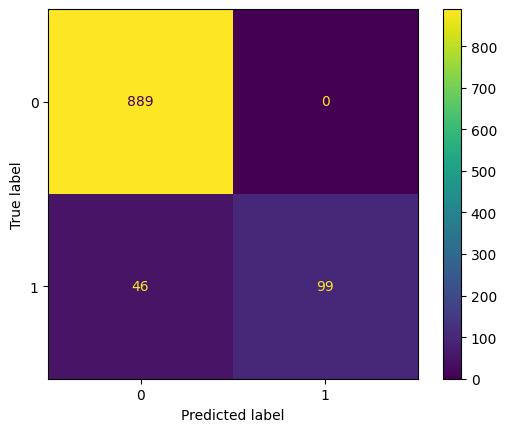

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [50]:
samples = [
    "free entry in 2 a wkly comp to win cash prize",
    "urgent! your account has been selected claim now",
    "click here to claim your free reward http://bit.ly/abc123",
    "hey bro what time dinner tonight",
    "can we meet tomorrow?",
    "win money now!!! limited offer!!!",
    "ok noted thanks boss"
]

sample_vec = vectorizer.transform(samples)
predictions = lr_model.predict(sample_vec)

for text, pred in zip(samples, predictions):
    label = "SPAM" if pred == 1 else "NOT SPAM"
    print(f"{text} --> {label}")

free entry in 2 a wkly comp to win cash prize --> SPAM
urgent! your account has been selected claim now --> SPAM
click here to claim your free reward http://bit.ly/abc123 --> SPAM
hey bro what time dinner tonight --> NOT SPAM
can we meet tomorrow? --> NOT SPAM
win money now!!! limited offer!!! --> NOT SPAM
ok noted thanks boss --> NOT SPAM
